In [1]:
pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install docx2pdf

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pymupdf

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install webdriver-manager

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install -U nltk

Note: you may need to restart the kernel to use updated packages.


In [44]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from sklearn.feature_extraction import text
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
from nltk.stem import PorterStemmer
from nltk import pos_tag, word_tokenize
from textblob import Word
from nltk.corpus import wordnet
from PyDictionary import PyDictionary
from hunspell import Hunspell

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/Camille/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/Camille/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [45]:
# These functions will be used for the compute function, and will determine whether a given
# element exists on the website or not.

def hasCss(xpath):
    try:
        driver.find_element_by_css_selector(xpath)
        return True
    except:
        return False
    
    
def hasXpath(xpath):
    try:
       
        driver.find_element_by_xpath(xpath)
        return True
    except:
        return False

def hasClass(xpath):
    try:
        driver.find_element_by_class_name(xpath)
        return True
    except:
        return False
    

In [46]:

# The following functions for text preprocessing, and will be used in the create_graph function.
# The following libraries will be initialized and used in the functions below.

dictionary=PyDictionary()

stop_words = stopwords.words('english')

lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()

validate = Hunspell()


# This function will find and return the syntatic category for a given word.

def pos_tagging(text):
    return pos_tag(word_tokenize(text))[0][1]

# This function will check to see if a given word is a stop word; If it is, it will return an empty string.

def check_stopword(corpus):
    if corpus in stop_words:
        return ""
    return corpus

# This function will lemmatize and stem a given word. It will use the POS tagging to lemmatize
# it to the best of its abilities.

def lemmatize_and_stem(corpus):
    lemmatized_word = lemmatizer.lemmatize(corpus, wordnet.VERB)
    stemmed_word = stemmer.stem(lemmatized_word)
    return stemmed_word
    
# This function will remove any symbols from the word. 

def remove_symbols(corpus):
        corpus = re.sub(r'\W+', ' ',corpus)
        corpus = re.sub(" \d+", " ", corpus)
        corpus = re.sub(' s ', ' ',corpus)
        corpus = re.sub(' ve ', ' ',corpus)
        corpus = re.sub(' m ', ' ',corpus)
        corpus = re.sub(' t ', ' ',corpus)
        return corpus
    
# This function will check to see if the processed word exists in the dictionary. If it 
# does not then it will return an empty string.

# We include the condition to check if a word exists in the dictionary. We include the condition to check 
# if the word capitalized is a valid word, since words such as Canada, Korea, etc. exist in the dictionary 
# but must be capitalized for them to be valid.

def ifValid(corpus):
    
    corpus = corpus.strip()
    
    if corpus is None:
        return "" 

    
    if validate.spell(corpus.capitalize()) and len(corpus)>1:
        return corpus
    
    elif validate.spell(corpus.lower()) and len(corpus)>1:
        return corpus
    else:
        return ""
        
    
# The following function will check to see if the word has typos and can be corrected. It
# is quite meticulous because sometimes the quality of text extraction from the OCR does not
# come out well because the text is hard to interpret.

# The function enters the if condition if it does not exist as a valid entry in the dictionary.
# Then, it will go through and check if it can be corrected, starting from its current length.
# The function will decrement the process until it is at the halfpoint for the word. It will then
# do the same process, but cut-off words at the front of the word if no word is found. 

# At any point in time if a correction can be found for the word the program will return that corrected
# word.


def correct(corpus):
    
    corpus = corpus.strip()
    
    if (dictionary.meaning(corpus)) is None:
        
        for i in range(len(corpus),int(len(corpus)/2)+1,-1):  
            
            word = Word(corpus[:i])
            spelling = (word.spellcheck()[0][0])
            
            if (spelling != corpus[:i]):
                return spelling
            
        for i in range(len(corpus),int(len(corpus)/2)+1,-1): 
            word = Word(corpus[i:])
            spelling = (word.spellcheck()[0][0])
            
            if (spelling != corpus[i:]):
                return spelling
        return "" ##check
        
    else:
        return corpus


In [47]:
from pathlib import Path
import time
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from time import sleep

In [48]:
# This function will leverage Google Drive API to convert the pdfs made in the compute function into Google documents, which has an automatic
# conversion process. 

# In order to use this, the user will have to input a username and password to authenticate the 
# process. The user can use their own email (we have no ability to access their email through this program),
# or an email is provided in the ReadME segment that is to be used solely for those who choose to not
# use their own accounts.

# After all of the pdfs are converted, the API will convert these documents to text files, which will then be processed
# in the create_graph function.

def save_it(decade_list,hyperlink_list,chosen_word,interval,start,end_year,total_books,title_list,books_entered):
    
    gauth = GoogleAuth()
    drive = GoogleDrive(gauth)

    counter = 0
    try:
        for i in range(len(decade_list)):
            
             sleep(2)
                
             file1 = drive.CreateFile()
        
             file1.SetContentFile(f'mergedImages{i}.pdf')
    
             file1.Upload(param={'convert': True})
        
             file2 = drive.CreateFile({'id': file1['id']})
    
             file2.GetContentFile(f'result{i}.txt',mimetype='text/plain')
        
             path = Path(f"result{i}.txt")
    
             path.write_text(path.read_text(encoding="latin-1"), encoding="utf8")
        
    except Exception:
        
        print("there was an error, please try again.")
         
    
    create_graph(decade_list,hyperlink_list,chosen_word,interval,start,end_year,total_books,title_list,books_entered)
        
        



In [49]:
import networkx as nx
import matplotlib.pyplot as plt
import nx_altair as nxa
import math
import numpy as np
from collections import defaultdict

In [67]:


# This function will create the text network graph(s) for the selected time period(s).

# The process involves a 5-step process:

    # 1) The program will read each text file separately. The function reads each line and only adds lines that contain the 
    #    word we are looking for. We created the words *chosen_word and just_in_case because oftentimes there are spelling errors
    #    in the OCR process. The function will then add each line separately to a list called text_list that is a list
    #    of all relevant strings separated into the different book. The function knows to break and where the next book
    #    when it sees the words breakpage, which was inserted after each breakpoint for this purpose.
    
    
    # 2) The program processes each string of text in text_list. The first step is to remove all symbols, then check
    #    if the word is a stopword, where if it is it skips it. Then, the word will be stemmed,then corrected for any 
    #    obvious spelling errors. If the word cannot be corrected, the program will skip the word. The processed list
    #    will then be saved to a list called processed_list.
    
    
    # 3) The program will create a double-nested dictionary, which will be headed by a key with the end year of the interval 
    #    that we will be looking at, and then the various syntatic categories (NN == noun, ADJ == adjective, all based
    #    on abbreviations in NLTK POS-tagging package). When the word of choice is found, the program will find all the 
    #    words surrounding it and add them to this nested dictionary with the following weights; if it is directly to the
    #    right or left of the word, it will be added to the dictionary with a weight of 5, unless it has already been 
    #    added,in which case 5 will be added to the current value. Words adjacent to the word of choice will be added up 
    #    until the word that is 4 words apart from the word of choice. The program will also check if it is possible
    #    for an adjacent word to exist (i.e. if the word of choice is cat, and the sentence is 'this is cat', there cannot
    #    be a word to the right of cat, thus the program checks for this by looping through certain conditions).
    
    # 4) Before moving on, the program will check if for each dictionary, there are enough words with weights
    #    greater than 5 that could make for a more accurate representation of which words are most associated
    #    to our word of choice, where if there are, it will delete all words with weights less than 6. The program will find 
    #    and append each adjacent word in the processed list next to the book title(s) that it was found to be associated with 
    #    the word of choice in to a list named final_list. The link(s) to the book(s) will also be attributed with them.
    
    
    # 5) Lastly, the graphs for each adjacency list will be made. For each interval, the program will first add a node with the word
    #    of choice to the center of the graph, then loop through each keyword inside the adjacency dictionary of that interval.
    #    the position of the node will depend on its syntatic category, and all the relevant information about the name, size_list 
    #    (which will vary depending on its weight) and position of the node will be appended to temporary lists and dictionaries, 
    #    nodes_list and pos_list, which will then be appended to pos_lists, nodes_lists, and sizes_lists and refreshed.
    
    #    The graphs will then be displayed with these lists and dictionaries. There is a boolean to check whether there is only one
    #    graph, since if there is axis will be flattened since if it is then axis will have 2 dimensions.
    
    #    The list that contains a reference to the book title and hyperlinks for each associated word will be displayed
    #    below the graph.
                 

def create_graph(decade_list,hyperlink_list,whole_word,interval,start,end_year,total_books,title_list,books_entered):
    
    # This function will be what gets rid of unnecessary keys from the dictionary later on.
    
    def getRidOfKeys(adjacency,year):
        
        key_list = (list(adjacency.keys()))
        
        for i in range(len((key_list))):
    
            grammar_list = list((adjacency[key_list[i]].keys()))
        
            tmp_count = 0
            
            while (tmp_count<len(grammar_list)):
            
                if None or adjacency[key_list[i]][grammar_list[tmp_count]] < 6 or grammar_list[tmp_count] == whole_word:
        
                    del adjacency[key_list[i]][grammar_list[tmp_count]]
                    tmp_count+=1
                
                else:
                
                    tmp_count+=1
                    
        return adjacency
    
    
    
    if len(whole_word.split(" "))>1:
        
        whole_word = whole_word.split(" ")[0]
    
    
              
    interval = int(interval)
    start = int(start)
    end_year = int(end_year)
    
    
    final_list = defaultdict()
    adj_list= defaultdict(lambda: defaultdict(lambda: defaultdict()))
    text_list = []
    line = list()
    counter = 0
    processed_list= []
    
    just_in_case = whole_word.lower()[:int(len(whole_word)/2)]
    
    chosen_word = lemmatize_and_stem(whole_word)
    
    
    for i in range(len(decade_list)):
        
        tmp=[]
        
        with open(f"result{i}.txt", "r") as f: 
                g = ""
            
                texts= f.readlines()  
        
                for text in texts:
                
                    text = text.lower()
                    
                    if 'breakpage' in text:
                        
                        tmp.append(g)
                        g=""
                    
                    elif 'translated and' not in text and 'â»' not in text and 'emarks' not in text and 'age count' not in text and 'ublished' not in text and 'in this book' not in text and 'read for' not in text and 'No preview available for this pa' not in text and  (text.isspace()== False) and text!="" and "riginal from" not in text:
                        
                        if chosen_word in text or just_in_case in text:
                            
                            if (chosen_word in text):
                            
                                text=(text)[4:-5]
                                text = text.strip()
                                
                                
                                before = ""
                                after = ""
                                
                                
                                
                                for i in range(len(text.split(chosen_word))-1):
                        
                                    before=(text.split(chosen_word)[i])
                                    after=(text.split(chosen_word)[i+1])
                                    if (i == len(text.split(chosen_word))-2):
                                        
                                        if (after.split(" ")[0] in whole_word):
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[1:13])
                                        else:
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[:12])
                                            
                                        if (before not in g):
                                            g+=before+" "+whole_word+" "
                                        if (after not in g):
                                            g+=after
                                            
                                    else:
                                        
                                        if (after.split(" ")[0] in whole_word):
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[1:13])
                                        else:
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[:12])
                                            
                                        if (before not in g):
                                            
                                            g+=before+" "+whole_word+" "
                                            
                                        if (after not in g):
                                            g+=after+" "+whole_word+" "
                                        
                                        
                                        
                                        
                               
                                
                            else:
                            
                                text=(text)[4:-5]
                                text = text.strip()
                                
                                
                                before = ""
                                after = ""
                                
                                for i in range(len(text.split(just_in_case))-1):
 
                                    before=(text.split(just_in_case)[i])
                                    after=(text.split(just_in_case)[i+1])
                                
                                        
                                    if (i == len(text.split(chosen_word))-2):
                                        
                                        if (after.split(" ")[0] in whole_word):
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[1:13])
                                        else:
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[:12])
                                        if (before not in g):
                                            g+=before+" "+whole_word+" "
                                        if (after not in g):
                                            g+=after
                                            
                                    else:
                                        
                                        if (after.split(" ")[0] in whole_word):
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[1:13])
                                        else:
                                            before=" ".join(before.split(" ")[:12])
                                            after=" ".join(after.split(" ")[:12])
                                        if (before not in g):
                                            g+=before+" "+whole_word+" "
                                        if (after not in g):
                                            g+=after+" "+whole_word+" "

    
        text_list.append(tmp)

    
    for i in range(len(text_list)):
        h=""
        tmp = []
        for j in range(len(text_list[i])):
            h=""
            for k in range(len(text_list[i][j].split(" "))):
                
                if (text_list[i][j].split(" ")[k] == whole_word):
                    h+=whole_word+" "
                    continue
        
                u=remove_symbols(text_list[i][j].split(" ")[k]).lower()
                        
                l=check_stopword(u)
                
                if (l.isspace() == True):
                    continue
                else:
                    sample = lemmatize_and_stem(l)
                    
                    if (sample.isspace()==True):
                        continue
                    else:
                    
                        sample2 = str(correct(sample))
                    
                        if (sample2 == 'None'):
                        
                            continue
                    
                        else:
                            valid = ifValid(sample2)

                        
                            if (valid == ""):
                                continue
                            else:
                                h+=valid + " "
            tmp.append(h)
        
        processed_list.append(tmp)
        
# Create edges that are going backward.
    
    num_key_list = []
    
    for i in range(len(decade_list)):
        
        year = decade_list[i]
        num_keys = 0
        
        for j in range(len(processed_list[i])):
            
            for k in range(len(processed_list[i][j].split())):
            
                if (whole_word in processed_list[i][j].split()[k] or just_in_case in processed_list[i][j].split()[k]):
    
                    if (k>0):
            
                
                        word1=processed_list[i][j].split()[k-1]
                    
                        if (word1 not in adj_list[year][pos_tagging(word1)].keys()):
                
                            adj_list[year][pos_tagging(word1)][word1] = 0  
                    
                
                        if (adj_list[year][pos_tagging(word1)][word1] < 1):
                
                            adj_list[year][pos_tagging(word1)][word1]=5

                    
                        else:
                            
                            num_keys +=1

                            adj_list[year][pos_tagging(word1)][word1]+=5
                            
                    if (k < len(processed_list[i][j].split())-1):
                
                        word3=processed_list[i][j].split()[k+1]
                    
                        if (word3 not in adj_list[year][pos_tagging(word3)].keys()):
       
                            adj_list[year][pos_tagging(word3)][word3] = 0   

                        if (adj_list[year][pos_tagging(word3)][word3] < 1):
            
                            adj_list[year][pos_tagging(word3)][word3]=5
            
                        else:

                            adj_list[year][pos_tagging(word3)][word3]+=5
                            num_keys +=1

 
                    if (k>1):
        
                        word1=processed_list[i][j].split()[k-2]
            
                        if (word1 not in adj_list[year][pos_tagging(word1)].keys()):
            
                            adj_list[year][pos_tagging(word1)][word1] = 0 
                    
                        if (adj_list[year][pos_tagging(word1)][word1] < 1):
                    
                            adj_list[year][pos_tagging(word1)][word1]=4
                    
                        else:
    
                            adj_list[year][pos_tagging(word1)][word1]+=4
        
                            if (adj_list[year][pos_tagging(word1)][word1] > 5):
                                num_keys +=1
                                
        
                    if (k < len(processed_list[i][j].split())-2):
        
                        word3=processed_list[i][j].split()[k+2]
            
                        if (word3 not in adj_list[year][pos_tagging(word3)].keys()):
        
                            adj_list[year][pos_tagging(word3)][word3] = 0   
            
                        if (adj_list[year][pos_tagging(word3)][word3] < 1):
                
                            adj_list[year][pos_tagging(word3)][word3]=4
                
                        else:
                        
                        
                            num_keys +=1

                            adj_list[year][pos_tagging(word3)][word3]+=4
                            
                            if (adj_list[year][pos_tagging(word3)][word3] > 5):
                                num_keys +=1
        
                    if (k>2):
                
                        word1=processed_list[i][j].split()[k-3]
                    
                        if (word1 not in adj_list[year][pos_tagging(word1)].keys()):
                
                            adj_list[year][pos_tagging(word1)][word1] = 0
                
                        if (adj_list[year][pos_tagging(word1)][word1] < 1):
                    
                            adj_list[year][pos_tagging(word1)][word1]=3
                    
                        else:

                            adj_list[year][pos_tagging(word1)][word1]+=3
                            
                            if (adj_list[year][pos_tagging(word1)][word1] > 5):
                                num_keys +=1
                            
                    if (k < len(processed_list[i][j].split())-3):
       
                        word3=processed_list[i][j].split()[k+3]
        
                        if (word3 not in adj_list[year][pos_tagging(word3)].keys()):
        
                            adj_list[year][pos_tagging(word3)][word3] = 0         

                        if (adj_list[year][pos_tagging(word3)][word3] < 1):
                
                            adj_list[year][pos_tagging(word3)][word3]=3
                
                        else:

                            adj_list[year][pos_tagging(word3)][word3]+=3
                            
                            if (adj_list[year][pos_tagging(word3)][word3] > 5):
                                num_keys +=1
        
                    if (k>3):

                        word1=processed_list[i][j].split()[k-4]
                    
                        if (word1 not in adj_list[year][pos_tagging(word1)].keys()):
                
                            adj_list[year][pos_tagging(word1)][word1] = 0 
                
                        if (adj_list[year][pos_tagging(word1)][word1] < 1):
                    
                            adj_list[year][pos_tagging(word1)][word1]=2
            
                        else:

                            adj_list[year][pos_tagging(word1)][word1]+=2  
                        
                            if (adj_list[year][pos_tagging(word1)][word1] > 5):
                                num_keys +=1
                        
                    if (k < len(processed_list[i][j].split())-4):
        
        
                        word3=processed_list[i][j].split()[k+4]
            
                        if (word3 not in adj_list[year][pos_tagging(word3)].keys()):
                    
                            adj_list[year][pos_tagging(word3)][word3] = 0  
            
         
                        if (adj_list[year][pos_tagging(word3)][word3] < 1):
            
                            adj_list[year][pos_tagging(word3)][word3]=2
                
                        else:

                            adj_list[year][pos_tagging(word3)][word3]+=2
                            
                            if (adj_list[year][pos_tagging(word3)][word3] > 5):
                                num_keys +=1

    
                    if (k>4):
            
                        word1=processed_list[i][j].split()[k-5]
            
                        if (word1 not in adj_list[year][pos_tagging(word1)].keys()):
                
                            adj_list[year][pos_tagging(word1)][word1] = 0  
                
                        if (adj_list[year][pos_tagging(word1)][word1] < 1):
                    
                            adj_list[year][pos_tagging(word1)][word1]=1
                    
                        else:
                        
                            adj_list[year][pos_tagging(word1)][word1]+=1
                            
                            if (adj_list[year][pos_tagging(word1)][word1] > 5):
                                num_keys +=1
                    
                    if (k < len(processed_list[i][j].split())-5):
        
                        word3=processed_list[i][j].split()[k+5]
            
                        if (word3 not in adj_list[year][pos_tagging(word3)].keys()):
        
                            adj_list[year][pos_tagging(word3)][word3] = 0 
   
                        if (adj_list[year][pos_tagging(word3)][word3] < 1):
        
                            adj_list[year][pos_tagging(word3)][word3]=1
                        else:

                            adj_list[year][pos_tagging(word3)][word3]+=1
                        
                            if (adj_list[year][pos_tagging(word3)][word3] > 5):
                                num_keys +=1
                                
            
        num_key_list.append(num_keys)
            
    
    
    
    for i in range(len(decade_list)):
        print(num_key_list[i])
        if (num_key_list[i]>=8):
            adj_list[decade_list[i]] = getRidOfKeys(adj_list[decade_list[i]],decade_list[i])

    
    for c in (range(len(decade_list))):
        
        key_list1 = (list(adj_list[decade_list[c]]))
    
        for i in range(len(key_list1)):
            tmp_list = []
            grammar_list1 = list((adj_list[decade_list[c]][key_list1[i]]))

            for j in range(len(grammar_list1)):
                tmp_list = []
                tmp = (grammar_list1[j])
            
                for k in range(len(processed_list[c])-1):
               
                    if tmp in processed_list[c][k]:
                    
                        # title is wrong.
                    
                        tmp_list.append(title_list[c][k])
                
                        tmp_list.append(hyperlink_list[c][k])
                    
                final_list[grammar_list1[j]] = (tmp_list)
    

    K = {}
    graph = nx.Graph()
    sizes_lists=list()
    nodes_lists=list()
    pos_lists=list()
    counter=0
    labels_lists = list()

# For each type of syntatic category, we assign a different position to the node.


#ADJ or ADV
    x_axis_1=52
    y_axis_1=52

#NOUN PROPN or PRON
    x_axis_2=47
    y_axis_2=52
    scale_2=0.05
    repeat=False
    added=0
    addedy=0

#VERB
    x_axis_3=52
    y_axis_3=48

# All other words existing in other syntatic categories.

    x_axis_4=47
    y_axis_4=48

    not_flat = False
    
    if (len(decade_list) == 1):
        fig, axes = plt.subplots(nrows=1, ncols=len(decade_list),figsize=(60,40))
        
    else:
        fig, axes = plt.subplots(nrows=1, ncols=len(decade_list),figsize=(100,40)) 
    
    if type(axes)!=np.ndarray : # Happens if nrows=ncols=1
        ax = np.array([[axes]])
        not_flat = True
    else:
        ax = axes.flatten()

    for x in range (len(decade_list)):
        
        labels_list = []
        K[x]=nx.Graph()
        year = decade_list[x]
        pos_list = dict()
        nodes_list = list()
        size_list = list()
        key_list1 = (list(adj_list[year]))
    
        size_list.append(10000)
        nodes_list.append(whole_word)
        pos_list[whole_word]=[50,50]

        for i in range(len(key_list1)):
    
        
        
            grammar_list1 = list((adj_list[year][key_list1[i]]))
            tmp_count = 0
    
            while (tmp_count<len(grammar_list1)):
        
                if ('JJ' in key_list1[i] or 'RB' in key_list1[i]):
            #print(grammar_list[tmp_count])
            
                    pos_list[grammar_list1[tmp_count]]=[x_axis_1,y_axis_1]
            #print(x_axis_1)
                    if (x_axis_1>=50):
                        x_axis_1+=0.35
                    if (y_axis_1>=0):
                        y_axis_1-=0.15
            
            
                elif ('NN' in key_list1[i]):
            #print(grammar_list[tmp_count])
                    pos_list[grammar_list1[tmp_count]]=[x_axis_2,y_axis_2]
            #print(x_axis_2)
            
                    if (x_axis_2>0):
                        if (x_axis_2<=45):
                            x_axis_2 = 48-added
                        elif (x_axis_2>=50):
                            x_axis_2 = 50-scale_2
                            #x_axis_2-=0.03
                
                
    
                    if (repeat == True and y_axis_2>=50.3):
            
                        y_axis_2-=0.15+scale_2  
                        scale_2+=scale_2
     
                
                    elif (repeat == True and y_axis_2<50.3):
                
                        y_axis_2 =  50.99
                        scale_2=0.02+added
                    
                        repeat=False
    
                    elif (y_axis_2<=50.5 and repeat == False):
            
                        print(grammar_list1[tmp_count])
                        repeat = True
                        scale_2=0.02
                        added +=0.05
                        x_axis_2=48-added
                        y_axis_2=52-added*2
 
                
                    else:    
                        y_axis_2-=0.15+scale_2
                        scale_2+=scale_2
                
                    if (y_axis_2<=50.99 and repeat == False):
                        repeat = False
      
                        y_axis_2-=0.15+scale_2   
   
                elif ('VB' in key_list1[i]):
                    pos_list[grammar_list1[tmp_count]]=[x_axis_3,y_axis_3]
            
                    if (x_axis_3>=0):
                        x_axis_3+=0.35
                    if (y_axis_3<=50):   
                        y_axis_3+=0.15
            
                else:
                    pos_list[grammar_list1[tmp_count]]=[x_axis_4,y_axis_4]
            
                    if (x_axis_4<=50):
                        x_axis_4+=0.35
            
                    if (y_axis_4<=50):
                        y_axis_4-=0.15
            
            
                nodes_list.append(grammar_list1[tmp_count])
                K[x].add_edge(whole_word,(grammar_list1[tmp_count]),weight=(adj_list[year][key_list1[i]][grammar_list1[tmp_count]]))
                size_list.append((math.pow(adj_list[year][key_list1[i]][grammar_list1[tmp_count]],2)*6+4000))
        
                tmp_count+=1

        labels = (nx.get_edge_attributes(K[x],'weight') )  
        
        if labels!="":
            labels_lists.append(labels)
            
        pos_lists.append(pos_list)
        sizes_lists.append(size_list)
        nodes_lists.append(nodes_list)

    
    if (len(labels_lists)==0):
        print("There were no closely associated words found, please increment the number of books you go through.")
    
    else:
        
        if (not_flat == False):

            for i in range(len(decade_list)):    
    
                nx.draw_networkx_edge_labels(K[i],pos=pos_lists[i],edge_labels=labels_lists[i])
                nx.draw_networkx(K[i],pos=pos_lists[i],node_size=sizes_lists[i],nodelist=nodes_lists[i],ax=ax[i])
            
        else:
            for i in range(len(decade_list)):    
                print(f"The number of books entered for this graph is {books_entered[i]}")
                nx.draw_networkx_edge_labels(K[i],pos=pos_lists[i],edge_labels=labels_lists[i])
                nx.draw_networkx(K[i],pos=pos_lists[i],node_size=sizes_lists[i],nodelist=nodes_lists[i],ax=ax[i,0])
            

        for i in range(len(final_list.keys())):
            print(list(final_list.keys())[i])
            for j in range(len(final_list[list(final_list.keys())[i]])):
                print(final_list[list(final_list.keys())[i]][j])
            print("\n")   


In [51]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [52]:
text = widgets.Text(
    value='enter here',
    placeholder='Type something',
    description='String:',
    disabled=False
)


In [53]:
import requests
from PIL import Image
import selenium
import re
from langdetect import detect
from PIL import Image
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from time import sleep
from traceback import print_exc
import urllib
from textblob import TextBlob
from selenium.webdriver.common.keys import Keys
from docx import Document
from selenium.common.exceptions import WebDriverException
from selenium.webdriver.chrome.options import Options
from selenium import webdriver
from textblob import TextBlob
from selenium import webdriver
from webdriver_manager.firefox import GeckoDriverManager
import img2pdf
import sys

In [54]:

# This function will scrape through all of the books.


    #    The program will first install geckodriver, then open the webscraper and search for the selected word on 
    #    google books, along with the selected interval period. It will also set the settings to only see books that
    #    are either fully accessible or can be previewed.
    #    
    #    
    
    
    #    The program processes each string of text in text_list. The first step is to remove all symbols, then check
    #    if the word is a stopword, where if it is it skips it. Then, the word will be stemmed,then corrected for any 
    #    obvious spelling errors. If the word cannot be corrected, the program will skip the word. The processed list
    #    will then be saved to a list called processed_list.



def compute(chosen_word,interval,start,end_year,total_books,keywords):

    interval = int(interval)
    start = int(start)
    end_year = int(end_year)
    total_books = int(total_books)
    screenshot_max = 10
    Image.MAX_IMAGE_PIXELS = None
    
    
    # If there exists more than one keyword, then we are going to increment the number of screenshots we take for a given
    # book, and increase the number of books that we go through, the reason for this being that not all of the 
    # screenshots are going to contain the word we are seeking to understand (some will solely be segments
    # of the book that contain the keyword(s)).
    
    if (keywords!=""):
        if (total_books<20):
            total_books = total_books*2
        chosen_word += " "+ keywords
        screenshot_max = 20
    
    # This function will change the contrast of the image, to make the background segment of the 
    # image not visible.
    
    def change_contrast(img, level):
        factor = (300 * (level + 450)) / (370 * (259 - level))
        def contrast(c):
            return 128 + factor * (c - 150)
        return img.point(contrast)
    
    # This function will merge all of the taken screenshots for a given interval
    # together into one image.
    
    def merge_images_vertically(imgs):

        widths, heights = zip(*(i.size for i in imgs))
        width_of_new_image = max(widths)  #take minimum width
        height_of_new_image = sum(heights)

        new_im = Image.new('RGB', (width_of_new_image, height_of_new_image))
        new_pos = 0
        
        for im in imgs:
            new_im.paste(im, (0, new_pos))
            new_pos += im.size[1] #position for the next image
        new_im.save('mergedBooks.png') #change the filename if you want

   
    error_found = False
    
    driver = webdriver.Firefox(executable_path=GeckoDriverManager().install())
    
    try:
        driver.get("https://books.google.com/")
        driver.find_element_by_css_selector('#oc-search-input').send_keys(chosen_word)
        driver.find_element_by_css_selector("#oc-search-button > input:nth-child(1)").click()
        decade_count = 0

        # These three lists initialize the lists that will store decades, hyperlinks, 
        # and titles, and used later on to create graphs.

        decade_list = []
        hyperlink_list = []
        title_list = []
        books_entered = []
        
        # curr_year will be the variable that is the end of the current interval that we are looking
        # at. 

        curr_year = int(start) + int(interval)

        prev = start
        
        book_name = []

        year_count=0


    # Iterates through this loop until the year that we are looking for has been reached.

        while (end_year>=curr_year):


            end_of_page = False

            decade_list.append(curr_year)

            c=0
            break_point = []

            sleep(2) 

            if (prev == start):

                view = driver.find_elements_by_class_name("KTBKoe")[0]
                view.click()

                driver.find_element_by_css_selector("div.EwsJzb:nth-child(1) > g-menu:nth-child(1) > g-menu-item:nth-child(2) > div:nth-child(1) > a:nth-child(1)").click()
                sleep(2)
                if hasCss(".std > a:nth-child(1)"):
                    driver.find_element_by_css_selector("#oc-search-button > input:nth-child(1)").click()




            sleep(3)
            date=driver.find_elements_by_class_name("KTBKoe")[2]
            date.click()

            custom = driver.find_element_by_css_selector("div.EwsJzb:nth-child(1) > g-menu:nth-child(1) > g-menu-item:nth-child(5) > div:nth-child(1) > div:nth-child(1) > span:nth-child(1)")
            custom.click()

            sleep(2)

            driver.find_element_by_css_selector("#OouJcb").send_keys(prev)
            driver.find_element_by_css_selector("#rzG2be").send_keys(curr_year)
            driver.find_element_by_css_selector(".Ru1Ao").click()


            page=2
            num_image=0


            authorList = []
            tmpHyper = []
            tmpTitle = []

        
            while (len(tmpHyper)<total_books and end_of_page == False):

                num_books = len(driver.find_elements_by_class_name("Yr5TG"))
                
                if (num_books ==0):
                    raise RuntimeError("No books were found, please edit your input and try again.")
                    driver.quit()
  
        # This counts the number of books and the variable count is
        # counting the iteration number.

        # The program will only do this once the crawler
        # has arrived to a new page.



        # Book count will keep track of which book we are on on the
        # page, and elems will contain all of the links to the books
        # that we will use to enter each book.

                book_count=0
                sleep(1)
                hyp_count = 1


            # Then, the program will loop through all of the found books here.
            # Check if we have seen this book already ; we will do this by checking if the book name exists already in the book_name
                
                tmp = 0
                curr = 0

                for i in range(1,num_books):

                    same_author = False

                    if (len(tmpHyper)>=total_books):

                        break

                    hyp_count+=1

                    isValid = False

                    in_list = True

                    sleep(2)  



                    found = True 

                    driver.switch_to.default_content()
                    
                    elem = driver.find_element_by_xpath(f"/html/body/div[6]/div/div[10]/div[1]/div/div[2]/div[2]/div/div/div[{i}]/div[2]/a/h3")

                    raw_title = elem.text


                    elem.click()
                    sleep(2)
        
                    if (hasXpath("//span[text()='Language: ']/following-sibling::span")):

                        test = driver.find_element_by_xpath("//span[text()='Language: ']/following-sibling::span")
                        language = test.text.lower()[:2]

                    else:
                        try:
                            b = TextBlob(raw_title)
                            language = b.detect_language()

                        except Exception:
                            if ':' in raw_title or ';' in raw_title or '-' in raw_title or ',' in raw_title:
                                if ':' in title:
                                    language = detect(raw_title.split(":")[0])
                                elif ';' in title:
                                    language = detect(raw_title.split(";")[0])
                                elif '-' in title:
                                    language = detect(raw_title.split('-')[0])
                                else:
                                    language = detect(raw_title.split(',')[0])

                            else:
                                language = detect(raw_title)

                    driver.back() 

                    driver.switch_to.default_content()

                    sleep(3)


                    # If the book is not in english, or is a dictionary, the program will skip it, since
                    # users will not be able to make much use of information in those books.

                    if (language == 'en' and 'ictionar' not in raw_title):

                        author = ""

                        try:    
                            tmpVar = driver.find_element_by_css_selector(f"div.Yr5TG:nth-child({i}) > div:nth-child(2) > div:nth-child(3) > a:nth-child(1) > span:nth-child(1)")                                                
                            author = tmpVar.text
                        except Exception:
                            try:
                                tmpVar = driver.find_element_by_css_selector(f"div.Yr5TG:nth-child({i}) > div:nth-child(2) > div:nth-child(3) > span:nth-child(1)")  
                                author = tmpVar.text

                            except Exception:
                                pass

                        if (author!=""):
                            author = " ".join(author.split(" ")[:2]).lower()

                            if author not in authorList and author.isdigit()==False:
                                isValid = True
                                authorList.append(author)
                        else:
                            same_author = True





                        title = raw_title.lower()

                        if ':' in title or ';' in title or '-' in title or ',' in title:

                            first = ""
                            sec = ""

                            if ':' in title:

                                if (len(title.split(':'))>2):

                                    first = title.split(":")[0]+" "+title.split(":")[1]

                                    if ('page' not in sec):
                                        sec = title.split(":")[2]

                                else:

                                    first = title.split(':')[0]

                                    if ('page' not in sec):
                                        sec = title.split(":")[1]

                                first = re.sub('[^a-zA-Z0-9-_*.] ', ' ', first)
                                sec = re.sub('[^a-zA-Z0-9-_*.] ', ' ', sec)

                                if (any(first in word for word in authorList) == False and any(sec in word for word in authorList) == False):
                                    isValid = True
                                    authorList.append(first)
                                    authorList.append(sec)
                                else:
                                    isValid = False



                            elif ';' in title: 

                                if (len(title.split(';'))>2):

                                    first = title.split(";")[0]+" "+title.split(";")[1]

                                    if ('page' not in sec):
                                        sec = title.split(";")[2]

                                else:

                                    first = title.split(';')[0]


                                    if ('page' not in sec):  
                                        sec = title.split(";")[1]

                                first = re.sub('[^a-zA-Z0-9-_*.] ', ' ', first)
                                sec = re.sub('[^a-zA-Z0-9-_*.] ', ' ', sec)

                                if (any(first in word for word in authorList) == False and any(sec in word for word in authorList) == False):
                                    isValid = True
                                    authorList.append(first)
                                    authorList.append(sec)
                                else:
                                    isValid = False



                            elif '-' in title:

                                # copy this.

                                if (len(title.split('-'))>2):

                                    first = title.split("-")[0]+" "+title.split("-")[1]

                                    if ('page' not in sec):
                                        sec = title.split("-")[2]

                                else:

                                    first = title.split('-')[0]

                                    if ('page' not in sec):
                                        sec = title.split("-")[1]

                                first = re.sub('[^a-zA-Z0-9-_*.] ', ' ', first)
                                sec = re.sub('[^a-zA-Z0-9-_*.] ', ' ', sec)


                                if (any(first in word for word in authorList) == False and any(sec in word for word in authorList) == False):
                                    isValid = True
                                    authorList.append(first)
                                    authorList.append(sec)
                                else:
                                    isValid = False





                            elif ',' in title:

                                if (len(title.split(','))>2):

                                    first = title.split(",")[0]+" "+title.split(",")[1]

                                    if ('page' not in sec):

                                        sec = title.split(",")[2]

                                else:

                                    first = title.split(',')[0]

                                    if ('page' not in sec):

                                        sec = title.split(",")[1]

                                first = re.sub('[^a-zA-Z0-9-_*.] ', ' ', first)
                                sec = re.sub('[^a-zA-Z0-9-_*.] ', ' ', sec)

                                if (any(first in word for word in authorList) == False and any(sec in word for word in authorList) == False):
                                    isValid = True
                                    authorList.append(first)
                                    authorList.append(sec)
                                else:
                                    isValid = False



                        else: 
                            title = re.sub('[^a-zA-Z0-9-_*.] ', ' ', title)

                            if title not in authorList:
                                isValid = True
                                authorList.append(title)
                            else:
                                isValid = False





            # Sometimes, google books isn't formatted in the
            # way that the book is in the form of a pop up.

            # So, to account for this, we see if the website 
            # has more than one frame.

            # If it does, we switch the reference frame to the pop
            # up, else we keep it as is.


                    if (isValid and same_author == False):
                        

                        left = 25
                        top = 255
                        right = 1175
                        bottom = 720

                        

                        sleep(1)
                        
                        tmpTitle.append(title)

                        link = driver.find_element_by_css_selector(f"div.Yr5TG:nth-child({hyp_count}) > div:nth-child(2) > a:nth-child(1)")

                        tmpHyper.append(link.get_attribute("href"))

                        elem = driver.find_element_by_xpath(f"/html/body/div[6]/div/div[10]/div[1]/div/div[2]/div[2]/div/div/div[{i}]/div[2]/a/h3")

                        elem.click()
                        sleep(2)

                        try:
                            driver.switch_to.frame("s7Z8Jb")

                        except WebDriverException:
                            pass
                        
                        sleep(1)


            # Next, we check if the website contains the "View all"
            # button that helps us find the specific parts of the text
            # that contain the word that we are seeking to understand.

            # If it doesn't contain it, it will simply take a screenshot,
            # then exit.

                        try:
                            driver.find_element_by_css_selector('span.search-bar-link:nth-child(6)').click()

                            try:
                                driver.find_element_by_css_selector("#gb-get-book-content")
                                left = 150
                                #bottom = 200
                                driver.find_element_by_css_selector("#\:5 > img:nth-child(1)")

                            except Exception:

                                pass

                            curr_height=0


                            driver.execute_script("document.body.style.transform='scale(2.15)';")
                        
                            sleep(2)
                            elem = driver.find_element_by_class_name("scroll-background")




                            

                            total_height = float(elem.get_attribute("style").split("height: ")[1].split("px")[0])

                            sleep(2)

                            # While we have not reached the end of the page,
                            # we will screenshot all of the relevant sections
                            # of the book that contain the word.
    
                            # This loop will continue to scroll down until we have 
                            # reached the end of the page.

                            # I've noticed that sometimes, a book can have too many pages. This 
                            # might skew our representation of how the text network analysis looks.

                            # So, I am going to put a counter, and only allow
                            # a maximum of 8 screenshots per book, and 20 if there are keywords.

                            screenshot_count=0

                            not_first = False

                            while curr_height <= total_height and screenshot_count < screenshot_max:

                            # Give the program some time to load the book.

                                sleep(2)

                                driver.save_screenshot(f"{num_image}.png")                        
                                img = change_contrast(Image.open(f"{num_image}.png"),40)
                                area = (left, top, right, bottom)
                                img = img.crop(area)
                                img.save(f"{num_image}.png")
                                driver.execute_script("arguments[0].scrollBy(0, 210)",driver.find_element_by_class_name("overflow-scrolling"))
                                curr_height += driver.execute_script("return document.documentElement.scrollHeight")
                                screenshot_count+=1
                                num_image+=1

                            

    #______________________________________________________________________    

                            sleep(1)

                            if (curr_height!=total_height):
                
                                sleep(1)
                                difference = total_height - curr_height
                                driver.execute_script(f"arguments[0].scrollBy(0, {total_height})",driver.find_element_by_class_name("overflow-scrolling"))
                                driver.save_screenshot(f"{num_image}.png")                        
                                img = change_contrast(Image.open(f"{num_image}.png"),40)
                                area = (left, top, right, bottom)
                                img = img.crop(area)
                                img.save(f"{num_image}.png")

                                curr_height += driver.execute_script("return document.documentElement.scrollHeight")
                                screenshot_count+=1
                                num_image+=1



                        except Exception:
                            
                            curr_height=0
                            
                            driver.execute_script("document.body.style.transform='scale(2.15)';")
                        
                            sleep(2)
                            elem = driver.find_element_by_class_name("scroll-background")






                            total_height = float(elem.get_attribute("style").split("height: ")[1].split("px")[0])

                            sleep(2)

                        # While we have not reached the end of the page,
                        # we will screenshot all of the relevant sections
                        # of the book that contain the word.

                        # This loop will continue to scroll down until we have 
                        # reached the end of the page.

                        # I've noticed that sometimes, a book can have too many pages. This 
                        # might skew our representation of how the text network analysis looks.

                        # So, I am going to put a counter, and only allow
                        # a maximum of 20 screenshots per book

                            screenshot_count=0

                            not_first = False

                            while curr_height <= total_height and screenshot_count < 4:

                            # Give the program some time to load the book.

                                sleep(2)

                            

                                sleep(1)
                                driver.save_screenshot(f"{num_image}.png")                        
                                img = change_contrast(Image.open(f"{num_image}.png"),40)
                                area = (left, top, right, bottom)
                                img = img.crop(area)
                                img.save(f"{num_image}.png")
                                driver.execute_script("arguments[0].scrollBy(0, 210)",driver.find_element_by_class_name("overflow-scrolling"))
                                curr_height += driver.execute_script("return document.documentElement.scrollHeight")
                                screenshot_count+=1
                                num_image+=1

                           
    #______________________________________________________________________    

                            sleep(1)

                        
                        break_point.append(num_image)  
                        driver.execute_script("window.history.go(-1)")
                        driver.switch_to.default_content()
                        driver.execute_script("window.scrollBy(0, 100)","")

                        sleep(1)


                page += 1

                if (page>=13):
                    page = 13

                driver.switch_to.default_content()
                driver.forward()
                driver.back()
                driver.refresh()    
                driver.switch_to.default_content()

                sleep(3)

                try:   
                    select=f".AaVjTc > tbody:nth-child(1) > tr:nth-child(1) > td:nth-child({page}) > a:nth-child(1)"
                    
                    driver.find_element_by_css_selector(select).click()
                    
                except Exception:
                    
                    end_of_page = True



            imagelist = []
            
            hyperlink_list.append(tmpHyper)
            title_list.append(tmpTitle)
            
    
            if (len(hyperlink_list) == 0 and end_year == curr_year):

                print("There were no results fitting the requirements, please edit the variables in your entry.")
                driver.quit()

            else:

                books_entered.append(len(tmpHyper))
                
                for i in range(num_image):
                    if (i in break_point and i!=num_image-1):
                        tmp1=Image.open('between.png')
                        con1=tmp1.convert('RGB')
                        tmp=Image.open(f'{i}.png')
                        con=tmp.convert('RGB')
                        imagelist.append(con1)
                        imagelist.append(con)

                    elif (i==num_image-1):
                        tmp1=Image.open('between.png')
                        con1=tmp1.convert('RGB')
                        tmp=Image.open(f'{i}.png')
                        con=tmp.convert('RGB')
                        imagelist.append(con)
                        imagelist.append(con1)

                    else:
                        tmp=Image.open(f'{i}.png')
                        con=tmp.convert('RGB')
                        imagelist.append(con)

                
                merge_images_vertically(imagelist)
                
                image = Image.open('mergedBooks.png')
  

                pdf_bytes = img2pdf.convert(image.filename)
  

                file = open(f'mergedImages{decade_count}.pdf', "wb")
  

                file.write(pdf_bytes)

                image.close()
  

                file.close()
                

                prev = curr_year

                tmp=[str(i) for i in str(curr_year)]

                pre_start  = "".join(tmp[:2])

                pre_start = int(pre_start)

                suf_start  = "".join(tmp[2:])

                suf_start = int(suf_start)

                if (suf_start == 0):
                    pre_start +=1
                    curr_year = pre_start*100

                else:    
                    curr_year=pre_start*100+(suf_start+interval)
                    decade_count +=1

                tmp = 2
                driver.switch_to.default_content()

                while (tmp < page):
                    driver.back()
                    driver.refresh()
                    tmp+=1
                    sleep(2)


                year_count+=1

    except Exception as e:
        
        error_found= True
        print(e.__class__.__name__)
        if ('RuntimeError' in e.__class__.__name__):
            print("No books were found, please edit your variables and try again.")
            driver.quit()
            
        
        elif ('NoSuchWindowException' not in e.__class__.__name__ and 'NameError' not in e.__class__.__name__):
            driver.close()
            print("There was a network error, the program will restart.")
            compute(chosen_word,interval,start,end_year,total_books,"")
        
        elif ('NoSuchWindowException' in e.__class__.__name__):
            
            print("Browser has been closed, will quit the program.")
            driver.quit()
            quit()
            
        
            
            
           
        
    # If the program quits the function because of an exception, it will not go to the next functions and 
    # will terminate.
    
    if (error_found == False):
        
        driver.quit()
        save_it(decade_list,hyperlink_list,chosen_word,interval,start,end_year,total_books,title_list,books_entered)

enter the word, interval that you want to look at analysis, and the dates you want to start and end analysis


[Make sure to hit enter before writing in the next box]


Button(description='Submit', style=ButtonStyle())

Output()

Text(value="e.g. 'cat','blue'", description='Word')

Text(value="e.g. '1','2','10'", description='Interval')

...

Text(value="e.g. '1890','1920','2003'", description='End year')

Text(value="e.g. '12','33' (enter result> 10)", description='# of books to enter')

Text(value="'science love'(separate by space)", description='extra words')



====== WebDriver manager ======
Current firefox version is 78.15
Get LATEST geckodriver version for 78.15 firefox
Driver [/Users/Camille/.wdm/drivers/geckodriver/macos/v0.30.0/geckodriver] found in cache


Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?client_id=928778916940-22chr2crmov61kjmiqjddh6gq30129gn.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8090%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=offline&response_type=code

Authentication successful.
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Error: The Following Error occured: list index out of range
Erro

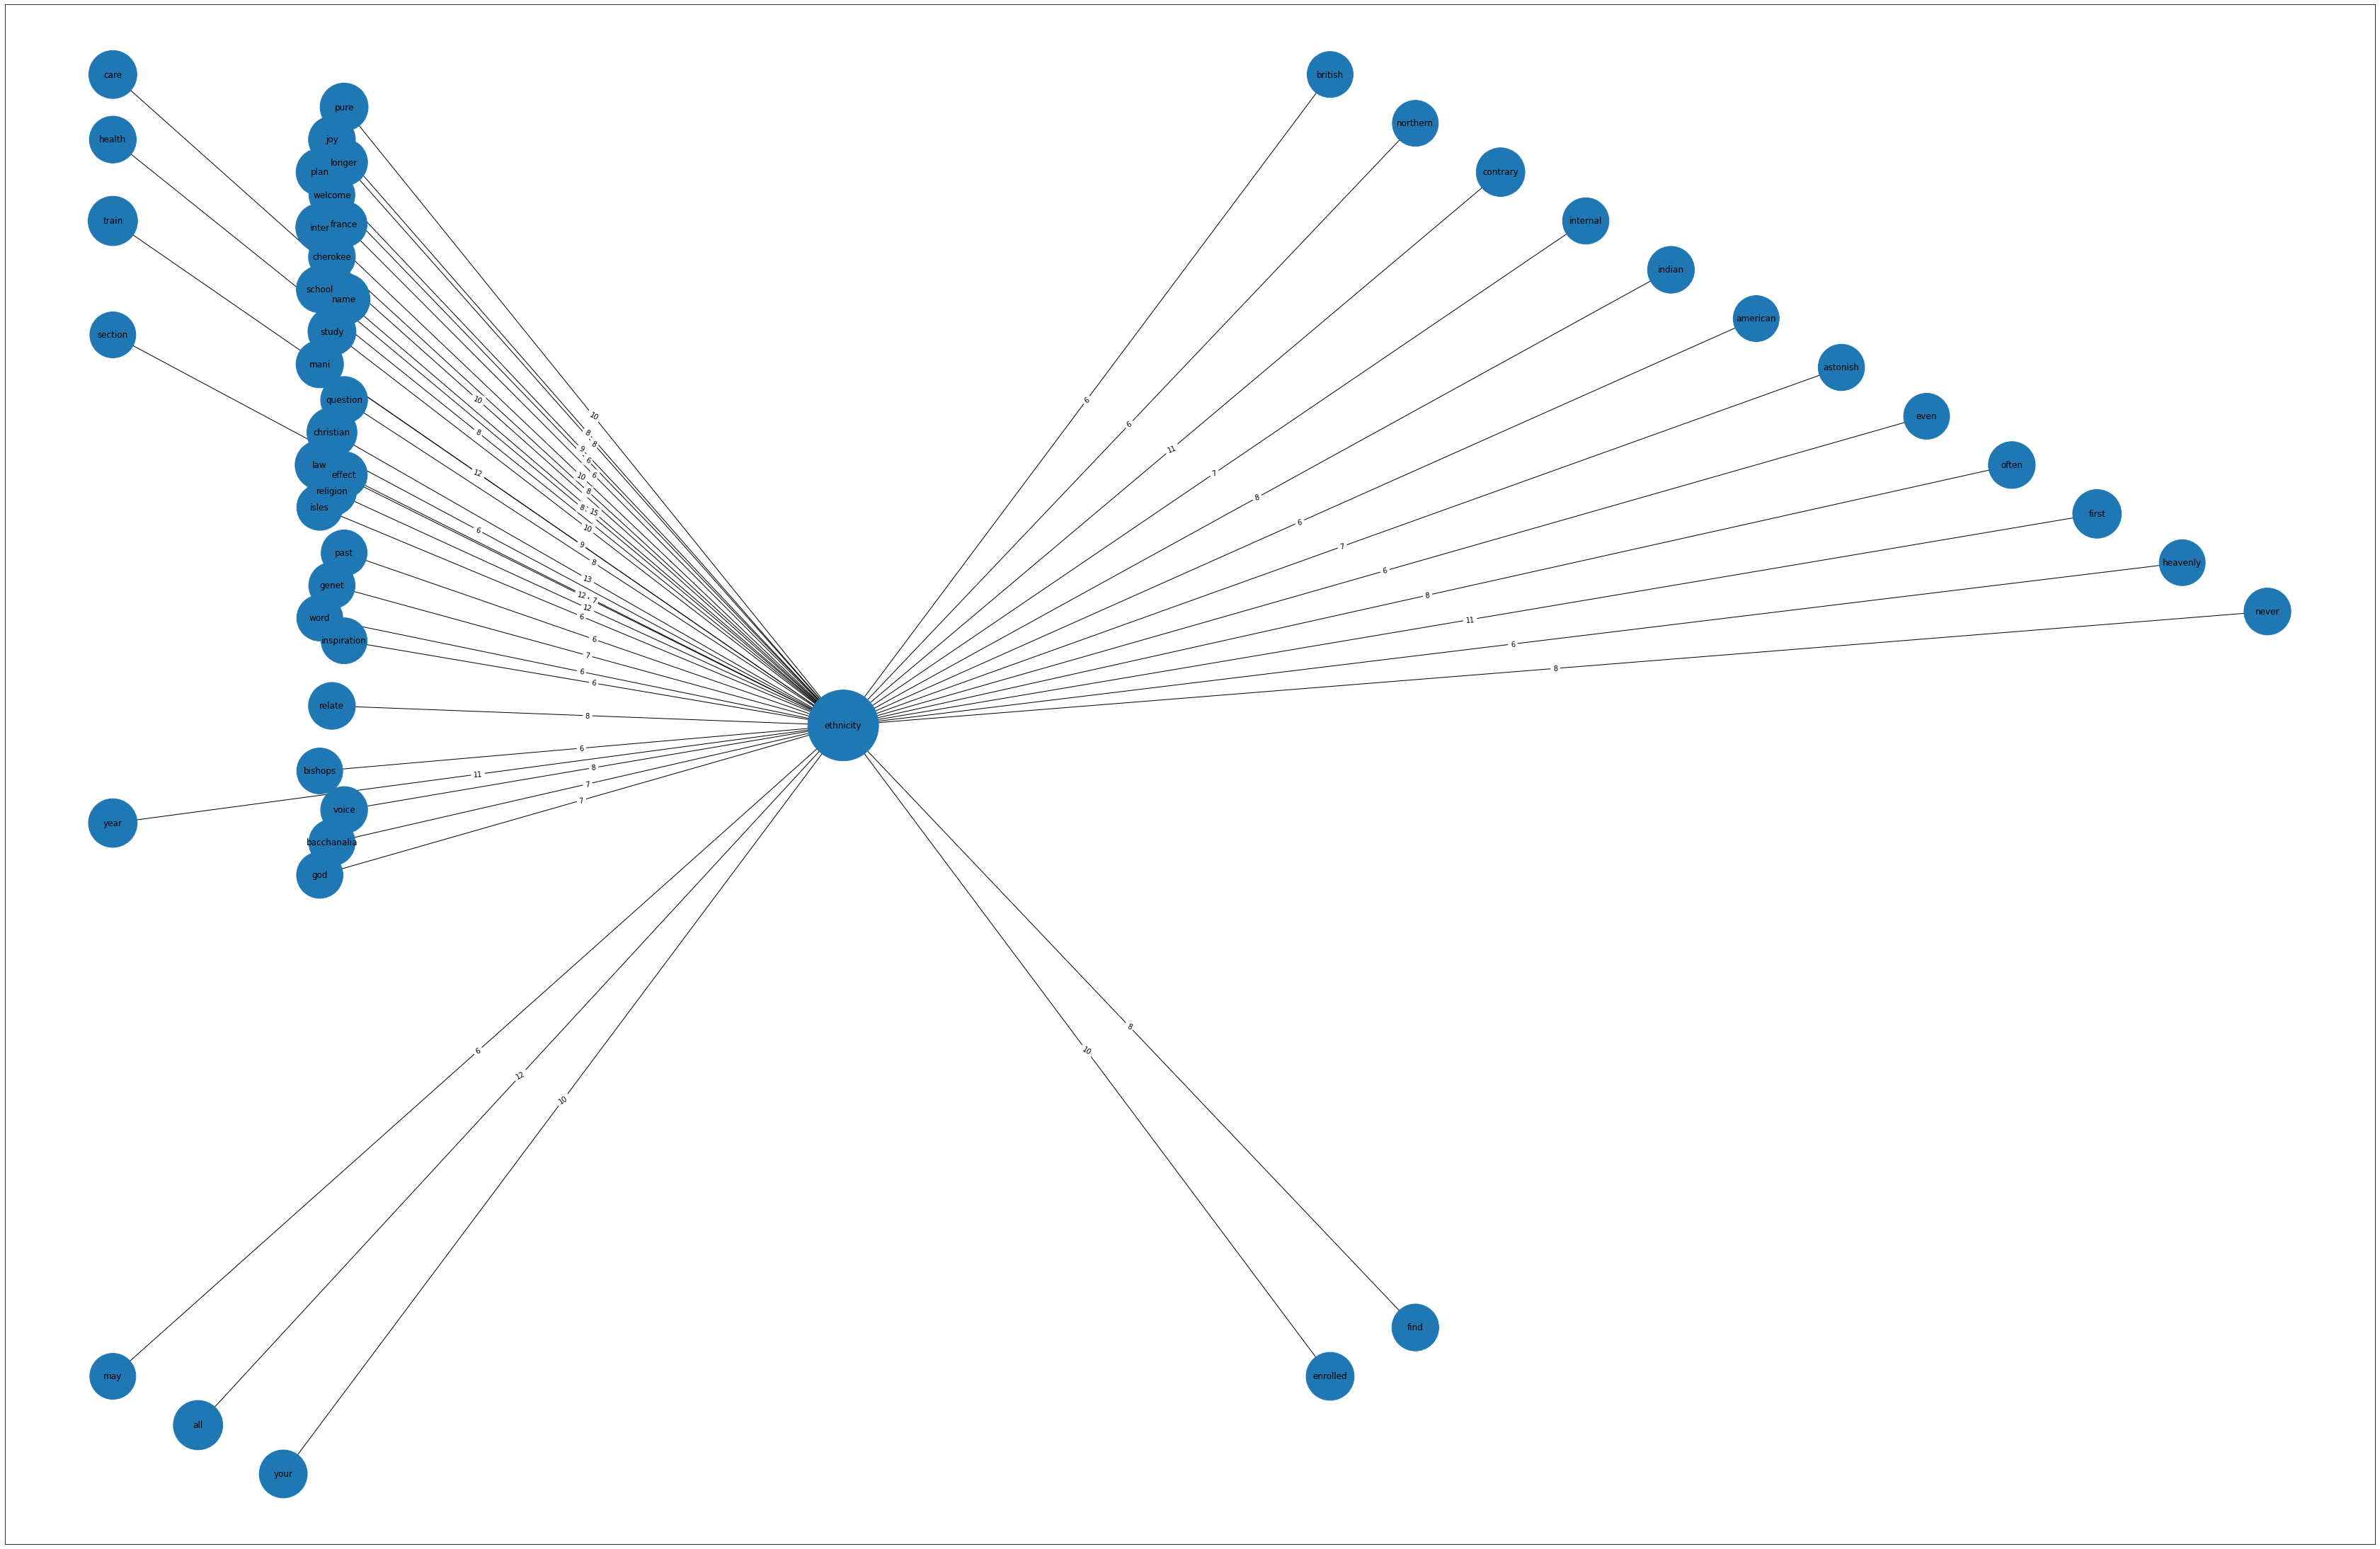

In [68]:
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import display

# This part of the program accounts for taking in the user input for the word of choice, start date, end date, interval
# , total books per interval, and (any) potential keyword(s).

class user_input:
    
    checklist = defaultdict()
    
     
    def handle_submit(self, text):
        user_input.checklist[text.description] = " "
        self.v = text.value
        return self.v
    
    
        

    def on_button_clicked(b):
        
        if len(user_input.checklist)>=5:
            
            if (f.start.value<=f.end_year.value):
                if (len(user_input.checklist)==6):
                    compute(f.word.value,f.interval.value,f.start.value,f.end_year.value,f.total_books.value,f.extra_keywords.value)
                else:
                    compute(f.word.value,f.interval.value,f.start.value,f.end_year.value,f.total_books.value,"")
            else:
                print("Please make sure that the start date is less than the end date.")
            
        else:
            print("Please fill in all of the entries first.")
            
    

    
    
    def __init__(self, 
                 word = "e.g. 'cat','blue'", 
                 interval = "e.g. '1','2','10'", 
                 start = "e.g. '1880','1920','2001'",
                 end_year = "e.g. '1890','1920','2003'",
                 total_books = "e.g. '12','33' (enter result> 10)",
                 extra_keywords = "'science love'(separate by space)"
            ):
                
     
        self.word = widgets.Text(description = 'Word',value = word)
        self.interval = widgets.Text(description = 'Interval',value = interval)
        self.start = widgets.Text(description = 'Start date',value = start)  
        self.end_year = widgets.Text(description = 'End year',value = end_year)
        self.total_books= widgets.Text(description = '# of books to enter',value = total_books)
        self.extra_keywords = widgets.Text(description = 'extra words',value = extra_keywords)
        
        self.button = widgets.Button(description="Submit")
        self.output = widgets.Output()
        self.button.on_click(user_input.on_button_clicked) 
        display(self.button,self.output)
        
        self.word.on_submit(self.handle_submit)    
        self.interval.on_submit(self.handle_submit)
        self.start.on_submit(self.handle_submit)
        self.end_year.on_submit(self.handle_submit)
        self.total_books.on_submit(self.handle_submit)
        self.extra_keywords.on_submit(self.handle_submit)
        
        display(self.word, self.interval, self.start,self.end_year,self.total_books,self.extra_keywords)
        
        
    
        
    
   

print("enter the word, interval that you want to look at analysis, and the dates you want to start and end analysis")
print("\n")
print("[Make sure to hit enter before writing in the next box]")
f = user_input()